# 2D Transformations with Homogeneous Coordinates

Homogeneous coordinates provide a systematic way to represent affine transformations (like translation, rotation, scaling, and reflection) as matrix multiplications. For 2D points $(x, y)$, we extend them to 3D homogeneous coordinates $(x, y, 1)$. This allows translations to be performed via matrix multiplication, unifying all affine transformations into a single matrix form.

In [ ]:
import numpy as np

# Define a 2D point (x, y) and convert to homogeneous coordinates (x, y, 1)
point_2d = np.array([2, 3])
point_homogeneous = np.append(point_2d, 1)

print(f"Original 2D point: {point_2d}")
print(f"Original homogeneous point: {point_homogeneous}")

Original 2D point: [2 3]
Original homogeneous point: [2 3 1]


### 1. Translation

Translation moves a point to a different location. The translation matrix for shifts `(tx, ty)` is:

In [ ]:
def translation_matrix(tx, ty):
    return np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1]
    ])

# Example: Translate by (1, 2)
tx, ty = 1, 2
T = translation_matrix(tx, ty)

# Apply the transformation
translated_point_homogeneous = T @ point_homogeneous
translated_point_2d = translated_point_homogeneous[:2]

print(f"\nTranslation matrix (tx={tx}, ty={ty}):\n{T}")
print(f"Translated homogeneous point: {translated_point_homogeneous}")
print(f"Translated 2D point: {translated_point_2d}")


Translation matrix (tx=1, ty=2):
[[1 0 1]
 [0 1 2]
 [0 0 1]]
Translated homogeneous point: [3 5 1]
Translated 2D point: [3 5]


### 2. Rotation

Rotation transforms a point around the origin by a given angle $\theta$ (in degrees). The rotation matrix is:

In [ ]:
def rotation_matrix(angle_degrees):
    theta = np.radians(angle_degrees)
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)
    return np.array([
        [cos_theta, -sin_theta, 0],
        [sin_theta, cos_theta, 0],
        [0, 0, 1]
    ])

# Example: Rotate by 45 degrees
angle = 45
R = rotation_matrix(angle)

# Apply the transformation to the original point
rotated_point_homogeneous = R @ point_homogeneous
rotated_point_2d = rotated_point_homogeneous[:2]

print(f"\nRotation matrix (angle={angle} degrees):\n{R}")
print(f"Rotated homogeneous point: {rotated_point_homogeneous}")
print(f"Rotated 2D point: {rotated_point_2d}")


Rotation matrix (angle=45 degrees):
[[ 0.70710678 -0.70710678  0.        ]
 [ 0.70710678  0.70710678  0.        ]
 [ 0.          0.          1.        ]]
Rotated homogeneous point: [-0.70710678  3.53553391  1.        ]
Rotated 2D point: [-0.70710678  3.53553391]


### 3. Scaling

Scaling changes the size of an object by factors `(sx, sy)` along the x and y axes. The scaling matrix is:

In [ ]:
def scaling_matrix(sx, sy):
    return np.array([
        [sx, 0, 0],
        [0, sy, 0],
        [0, 0, 1]
    ])

# Example: Scale by (2, 0.5)
sx, sy = 2, 0.5
S = scaling_matrix(sx, sy)

# Apply the transformation to the original point
scaled_point_homogeneous = S @ point_homogeneous
scaled_point_2d = scaled_point_homogeneous[:2]

print(f"\nScaling matrix (sx={sx}, sy={sy}):\n{S}")
print(f"Scaled homogeneous point: {scaled_point_homogeneous}")
print(f"Scaled 2D point: {scaled_point_2d}")


Scaling matrix (sx=2, sy=0.5):
[[2.  0.  0. ]
 [0.  0.5 0. ]
 [0.  0.  1. ]]
Scaled homogeneous point: [4.  1.5 1. ]
Scaled 2D point: [4.  1.5]


### 4. Reflection

Reflection (or mirroring) can be performed across the x-axis, y-axis, or origin. These can be thought of as scaling by -1 along a specific axis.

*   **Reflection across X-axis:** `sx = 1, sy = -1`
*   **Reflection across Y-axis:** `sx = -1, sy = 1`
*   **Reflection across Origin:** `sx = -1, sy = -1`

In [ ]:
# Reflection across X-axis (sx=1, sy=-1)
Rx = scaling_matrix(1, -1)
reflected_x_point_homogeneous = Rx @ point_homogeneous
reflected_x_point_2d = reflected_x_point_homogeneous[:2]

print(f"\nReflection across X-axis matrix:\n{Rx}")
print(f"Reflected across X-axis 2D point: {reflected_x_point_2d}")

# Reflection across Y-axis (sx=-1, sy=1)
Ry = scaling_matrix(-1, 1)
reflected_y_point_homogeneous = Ry @ point_homogeneous
reflected_y_point_2d = reflected_y_point_homogeneous[:2]

print(f"\nReflection across Y-axis matrix:\n{Ry}")
print(f"Reflected across Y-axis 2D point: {reflected_y_point_2d}")

# Reflection across Origin (sx=-1, sy=-1)
Ro = scaling_matrix(-1, -1)
reflected_o_point_homogeneous = Ro @ point_homogeneous
reflected_o_point_2d = reflected_o_point_homogeneous[:2]

print(f"\nReflection across Origin matrix:\n{Ro}")
print(f"Reflected across Origin 2D point: {reflected_o_point_2d}")


Reflection across X-axis matrix:
[[ 1  0  0]
 [ 0 -1  0]
 [ 0  0  1]]
Reflected across X-axis 2D point: [ 2 -3]

Reflection across Y-axis matrix:
[[-1  0  0]
 [ 0  1  0]
 [ 0  0  1]]
Reflected across Y-axis 2D point: [-2  3]

Reflection across Origin matrix:
[[-1  0  0]
 [ 0 -1  0]
 [ 0  0  1]]
Reflected across Origin 2D point: [-2 -3]


In [ ]:
# Install PyOpenGL and its accelerator
%pip install PyOpenGL PyOpenGL_accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 36.5 MB/s eta 0:00:00


Let's set up a visualization using `matplotlib` and `PyOpenGL` to see these transformations in action. We'll define a simple function to draw points and then apply each transformation.

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Required for 3D projections in some contexts, though we're mostly 2D here
from matplotlib.animation import FuncAnimation # For animations later, if needed

# We'll use a slightly different approach for visualization since we're staying in 2D
# For simplicity, we'll plot the points using matplotlib directly rather than a full OpenGL context for now.
# If a full interactive 3D OpenGL window is desired, it typically requires a separate windowing toolkit (e.g., Pygame, PyQt, GLFW).

# Let's redefine the original point for clarity in plotting
original_point = np.array([2, 3])

def plot_transformation(original_point, transformed_point, title):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(original_point[0], original_point[1], 'ro', markersize=8, label='Original Point')
    ax.plot(transformed_point[0], transformed_point[1], 'bo', markersize=8, label='Transformed Point')

    # Draw a line from origin to points for better visual
    ax.plot([0, original_point[0]], [0, original_point[1]], 'r--')
    ax.plot([0, transformed_point[0]], [0, transformed_point[1]], 'b--')

    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)
    ax.set_xlim(min(0, original_point[0], transformed_point[0]) - 1, max(0, original_point[0], transformed_point[0]) + 1)
    ax.set_ylim(min(0, original_point[1], transformed_point[1]) - 1, max(0, original_point[1], transformed_point[1]) + 1)
    ax.set_xlabel('X-axis')
    ax.set_ylabel('Y-axis')
    ax.set_title(title)
    ax.legend()
    plt.show()

Now, let's visualize each transformation using the plotting function.

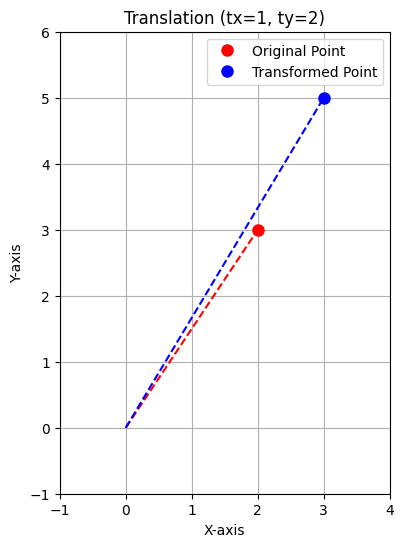

In [ ]:
# 1. Visualize Translation
# Using the previously calculated translated_point_2d
plot_transformation(original_point, translated_point_2d, 'Translation (tx=1, ty=2)')

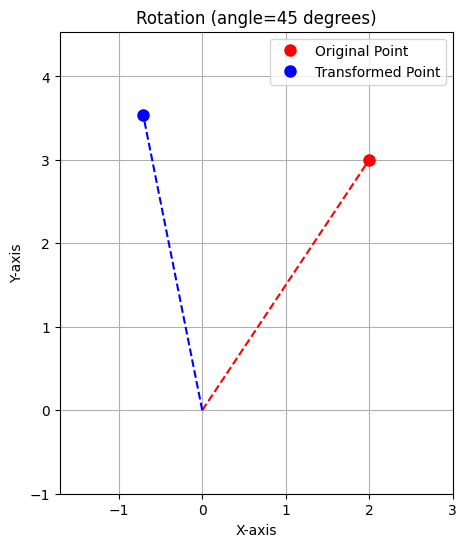

In [ ]:
# 2. Visualize Rotation
# Using the previously calculated rotated_point_2d
plot_transformation(original_point, rotated_point_2d, 'Rotation (angle=45 degrees)')

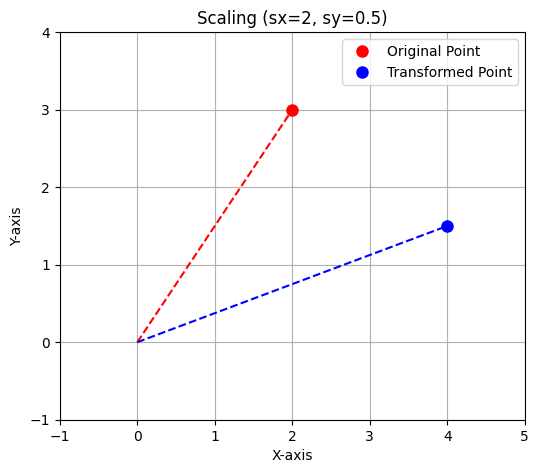

In [ ]:
# 3. Visualize Scaling
# Using the previously calculated scaled_point_2d
plot_transformation(original_point, scaled_point_2d, 'Scaling (sx=2, sy=0.5)')

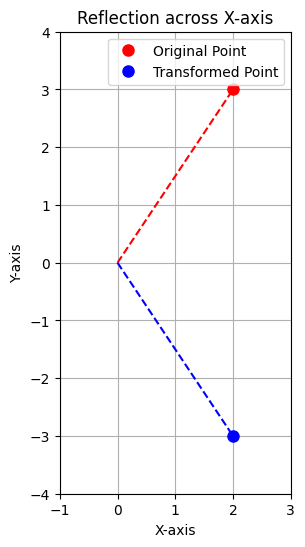

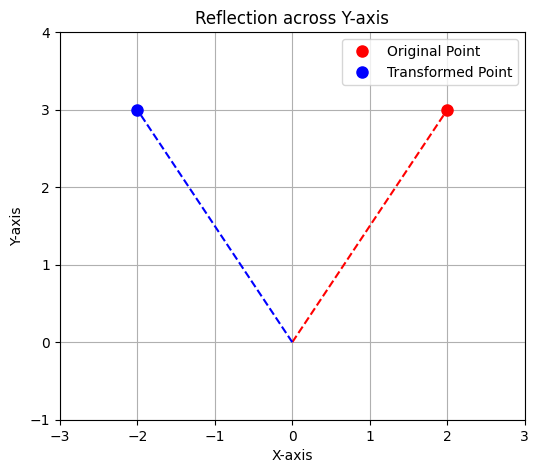

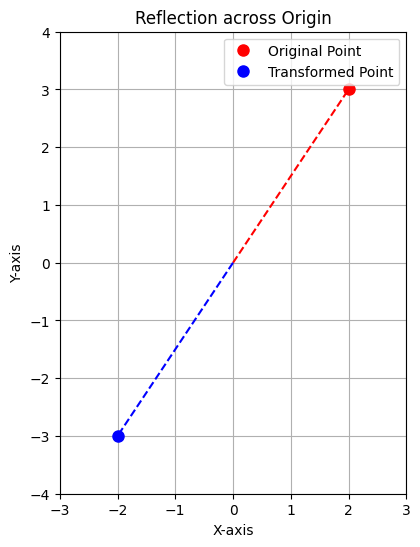

In [ ]:
# 4. Visualize Reflection

plot_transformation(original_point, reflected_x_point_2d, 'Reflection across X-axis')
plot_transformation(original_point, reflected_y_point_2d, 'Reflection across Y-axis')
plot_transformation(original_point, reflected_o_point_2d, 'Reflection across Origin')